# 10 · Comprobación con todas las configuraciones

Aplica el criterio del notebook 09 (límite del 1 % de falsas alarmas) a todas
las configuraciones entrenadas en el TFM, para comprobar que la elección no
dependía de haber comparado solo dos candidatos. Los cuatro ensayos de
hiperparámetros de 50 épocas se muestran aparte. Solo usa validación.

## Guía de lectura y ejecución

| Aspecto | Descripción |
|---|---|
| **Papel en el proyecto** | Comprueba la elección aplicando el mismo criterio del 1 % a todas las configuraciones entrenadas. |
| **Cuándo abrirlo** | Para comprobar que la elección no dependía de comparar solo dos candidatos (Figura 5 de la memoria). |
| **Comportamiento por defecto** | Muestra los resultados guardados. Se recalculan con `tools/run_all_models_01pct_comparison.py`. |
| **Entradas principales** | Predicciones de validación de las 14 configuraciones completas y de los cuatro ensayos de hiperparámetros. |
| **Salidas principales** | Rankings y tablas por clase y tamaño. |
| **Continuación** | `11_DFire_evaluacion_final_test.ipynb`. |

> **Para ejecutarlo:** usar el entorno Docker de notebooks (sección 4 del
> `README.md` principal). Volver a ejecutarlo requiere resultados intermedios
> (`artifacts/experiments/` y otras carpetas de `artifacts/`) que no están en el
> repositorio; ver `notebooks/README.md`.

## Resumen

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
import yaml
from IPython.display import display, Markdown, Image

roots = [Path(os.environ["TFM_PROJECT_ROOT"])] if os.environ.get("TFM_PROJECT_ROOT") else []
roots += [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((path for path in roots if (path / "tfm_pipeline.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Abrir el notebook dentro de TFM o definir TFM_PROJECT_ROOT.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import tfm_pipeline as pipeline

CONFIG_PATH = PROJECT_ROOT / "configs" / "all_models_01pct_comparison.yaml"
config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
assert config["split"] == "val" and config["test_locked"] is True

latest = pipeline.read_json(
    PROJECT_ROOT / "artifacts" / "13_all_models_01pct_comparison" / "validation" / "latest.json"
)
RUN_DIR = PROJECT_ROOT / latest["run_rel"]
summary = pipeline.read_json(RUN_DIR / "run_summary.json")
assert summary["test_inference_executed"] is False

ranked = pd.read_csv(RUN_DIR / "ranked_operating_points.csv")
full_sensitivity = ranked[
    (ranked.comparison_group == "full_training") & (ranked.scenario == "sensitivity")
].sort_values("rank")
winner = full_sensitivity.iloc[0]
previous = full_sensitivity[full_sensitivity.configuration == "yolo26s_768_eval768"].iloc[0]
display(Markdown(
    f"**Mejor recall medio con el criterio del 1 %:** {winner.label}, con recall macro "
    f"**{winner.macro_recall:.2%}** y F1 **{winner.micro_f1:.2%}**.  \n"
    f"**Modelo final (elegido en el notebook 09):** {previous.label}, recall macro **{previous.macro_recall:.2%}**, "
    f"F1 **{previous.micro_f1:.2%}** y recall de fuego **{previous.fire_recall:.2%}**."
))


**Mejor recall medio con el criterio del 1 %:** YOLO26s 640→640, con recall macro **79.86%** y F1 **71.50%**.  
**Modelo final (elegido en el notebook 09):** YOLO26s 768→768, recall macro **78.95%**, F1 **73.52%** y recall de fuego **78.53%**.

## Criterio

- Límite del 1 %: como máximo 7 de las 783 imágenes sin humo ni fuego con
  alguna alarma.
- Umbrales de humo y fuego independientes, de 0,16 a 0,60 en pasos de 0,01.
- **Ranking de sensibilidad** (criterio principal): mayor recall medio de humo
  y fuego; en caso de empate, mayor recall de la peor clase, F1 y precisión.
- **Ranking equilibrado**: mayor F1. Se muestra solo como referencia.
- Los ensayos de 50 épocas no son comparables con los entrenamientos completos
  de 100 épocas.

### 1. Comprobación de los datos de entrada

In [2]:
verification = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "tools" / "verify_all_models_01pct_comparison.py")],
    check=True, cwd=PROJECT_ROOT, capture_output=True, text=True,
)
verification_report = json.loads(verification.stdout)
display(pd.DataFrame([verification_report]))

coverage = pd.DataFrame([{
    "imágenes de validación": summary["images"],
    "imágenes negativas": summary["negative_images"],
    "configuraciones completas": summary["full_training_configurations"],
    "ensayos HP de 50 épocas": summary["hp_screening_configurations"],
    "parejas de umbrales": summary["class_threshold_points"],
    "máximo de alarmas": summary["maximum_negative_images_with_alarm"],
    "test consultado": summary["test_inference_executed"],
}])
display(coverage)


,status,run_id,configurations,full_training_configurations,hp_screening_configurations,class_threshold_points,maximum_negative_images_with_alarm,sensitivity_winner,balanced_winner,previous_comparison_reproduced,test_inference_executed
0,passed,20260914T213904Z_641e7db4,18,14,4,36450,7,yolo26s_640_eval640,yolov8s_768_eval640,True,False


,imágenes de validación,imágenes negativas,configuraciones completas,ensayos HP de 50 épocas,parejas de umbrales,máximo de alarmas,test consultado
0,1721,783,14,4,36450,7,False


## Resultados

### 2. Ranking de sensibilidad

Puesto,Configuración,Umbral humo,Umbral fuego,Recall humo,Recall fuego,Recall macro,Peor recall,Precisión micro,Recall micro,F1 micro,Negativas con alarma
1,YOLO26s 640→640,0.16,0.16,84.48%,75.24%,79.86%,75.24%,65.02%,79.43%,71.50%,7
2,YOLO26s 768→768,0.36,0.16,79.38%,78.53%,78.95%,78.53%,68.82%,78.91%,73.52%,7
3,YOLO26s 768→640,0.32,0.16,79.27%,77.06%,78.16%,77.06%,67.97%,78.06%,72.67%,7
4,YOLOv8s 768→640,0.49,0.17,75.62%,78.53%,77.08%,75.62%,68.84%,77.21%,72.79%,7
5,YOLO26n 640→640,0.19,0.16,80.21%,72.73%,76.47%,72.73%,63.71%,76.12%,69.37%,7
6,YOLOv8s 1024→768,0.50,0.16,74.69%,77.66%,76.17%,74.69%,67.84%,76.31%,71.83%,7
7,YOLOv8s 1024→1024,0.43,0.24,76.25%,73.94%,75.09%,73.94%,72.99%,74.99%,73.97%,7
8,YOLOv8s 640→640,0.45,0.27,77.08%,71.95%,74.52%,71.95%,75.35%,74.28%,74.81%,7
9,YOLOv8s 640→768,0.45,0.28,76.04%,72.55%,74.30%,72.55%,75.86%,74.14%,74.99%,7
10,YOLOv8s 1024→640,0.49,0.20,73.65%,74.89%,74.27%,73.65%,71.32%,74.33%,72.79%,7


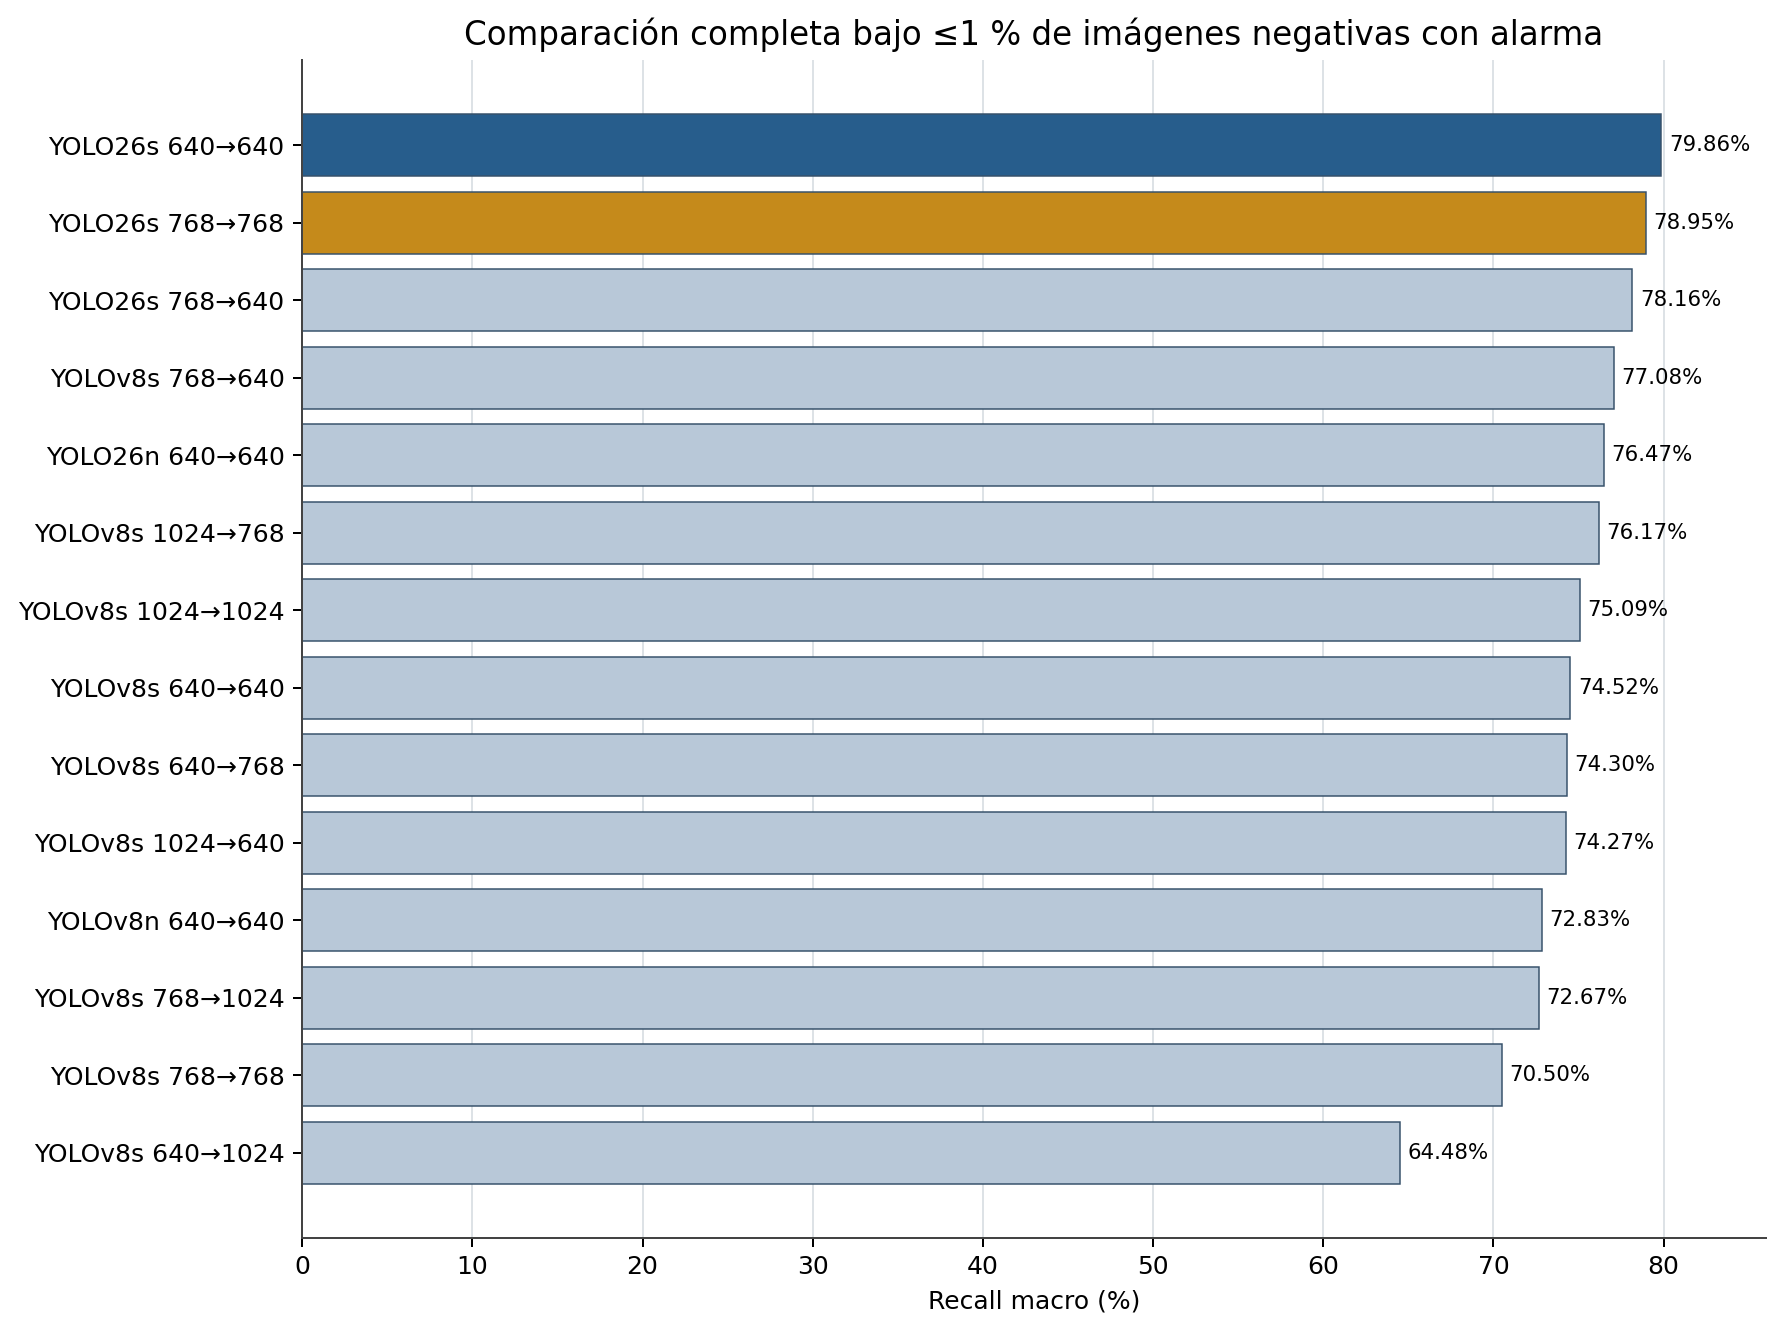

In [3]:
columns = [
    "rank", "label", "smoke_threshold", "fire_threshold", "smoke_recall", "fire_recall",
    "macro_recall", "minimum_class_recall", "micro_precision", "micro_recall", "micro_f1",
    "negative_images_with_alarm",
]
table = full_sensitivity[columns].rename(columns={
    "rank": "Puesto", "label": "Configuración", "smoke_threshold": "Umbral humo",
    "fire_threshold": "Umbral fuego", "smoke_recall": "Recall humo",
    "fire_recall": "Recall fuego", "macro_recall": "Recall macro",
    "minimum_class_recall": "Peor recall", "micro_precision": "Precisión micro",
    "micro_recall": "Recall micro", "micro_f1": "F1 micro",
    "negative_images_with_alarm": "Negativas con alarma",
})
display(table.style.format({
    "Umbral humo": "{:.2f}", "Umbral fuego": "{:.2f}", "Recall humo": "{:.2%}",
    "Recall fuego": "{:.2%}", "Recall macro": "{:.2%}", "Peor recall": "{:.2%}",
    "Precisión micro": "{:.2%}", "Recall micro": "{:.2%}", "F1 micro": "{:.2%}",
}).hide(axis="index"))
display(Image(filename=str(RUN_DIR / "figures" / "01_full_training_macro_recall.png"), width=1100))


Con este criterio, el primero es YOLO26s 640→640. Su ventaja en recall medio
sobre YOLO26s 768→768 es pequeña y viene sobre todo del humo, no del fuego.

### 3. YOLO26s 640→640 frente a 768→768

Aunque 640→640 tiene algo más de recall medio, lo reparte peor entre clases
(humo 84,48 %, fuego 75,24 %) que 768→768 (humo 79,38 %, fuego 78,53 %), y
detecta 3,3 puntos menos de fuego, la clase más difícil. Por eso se mantuvo la
elección de YOLO26s 768→768.

Configuración,Recall humo,Recall fuego,Peor recall,Recall macro,Precisión,Recall micro,F1,FP humo,FP fuego,FN humo,FN fuego
YOLO26s 640→640,84.48%,75.24%,75.24%,79.86%,65.02%,79.43%,71.50%,277,627,149,286
YOLO26s 768→768,79.38%,78.53%,78.53%,78.95%,68.82%,78.91%,73.52%,126,630,198,248


Frente a 640→640, 768→768 pierde **5.10 puntos** de recall de humo, pero gana **3.29 puntos** de recall de fuego, **3.29 puntos** en la peor clase, **3.81 puntos** de precisión y **2.02 puntos** de F1.

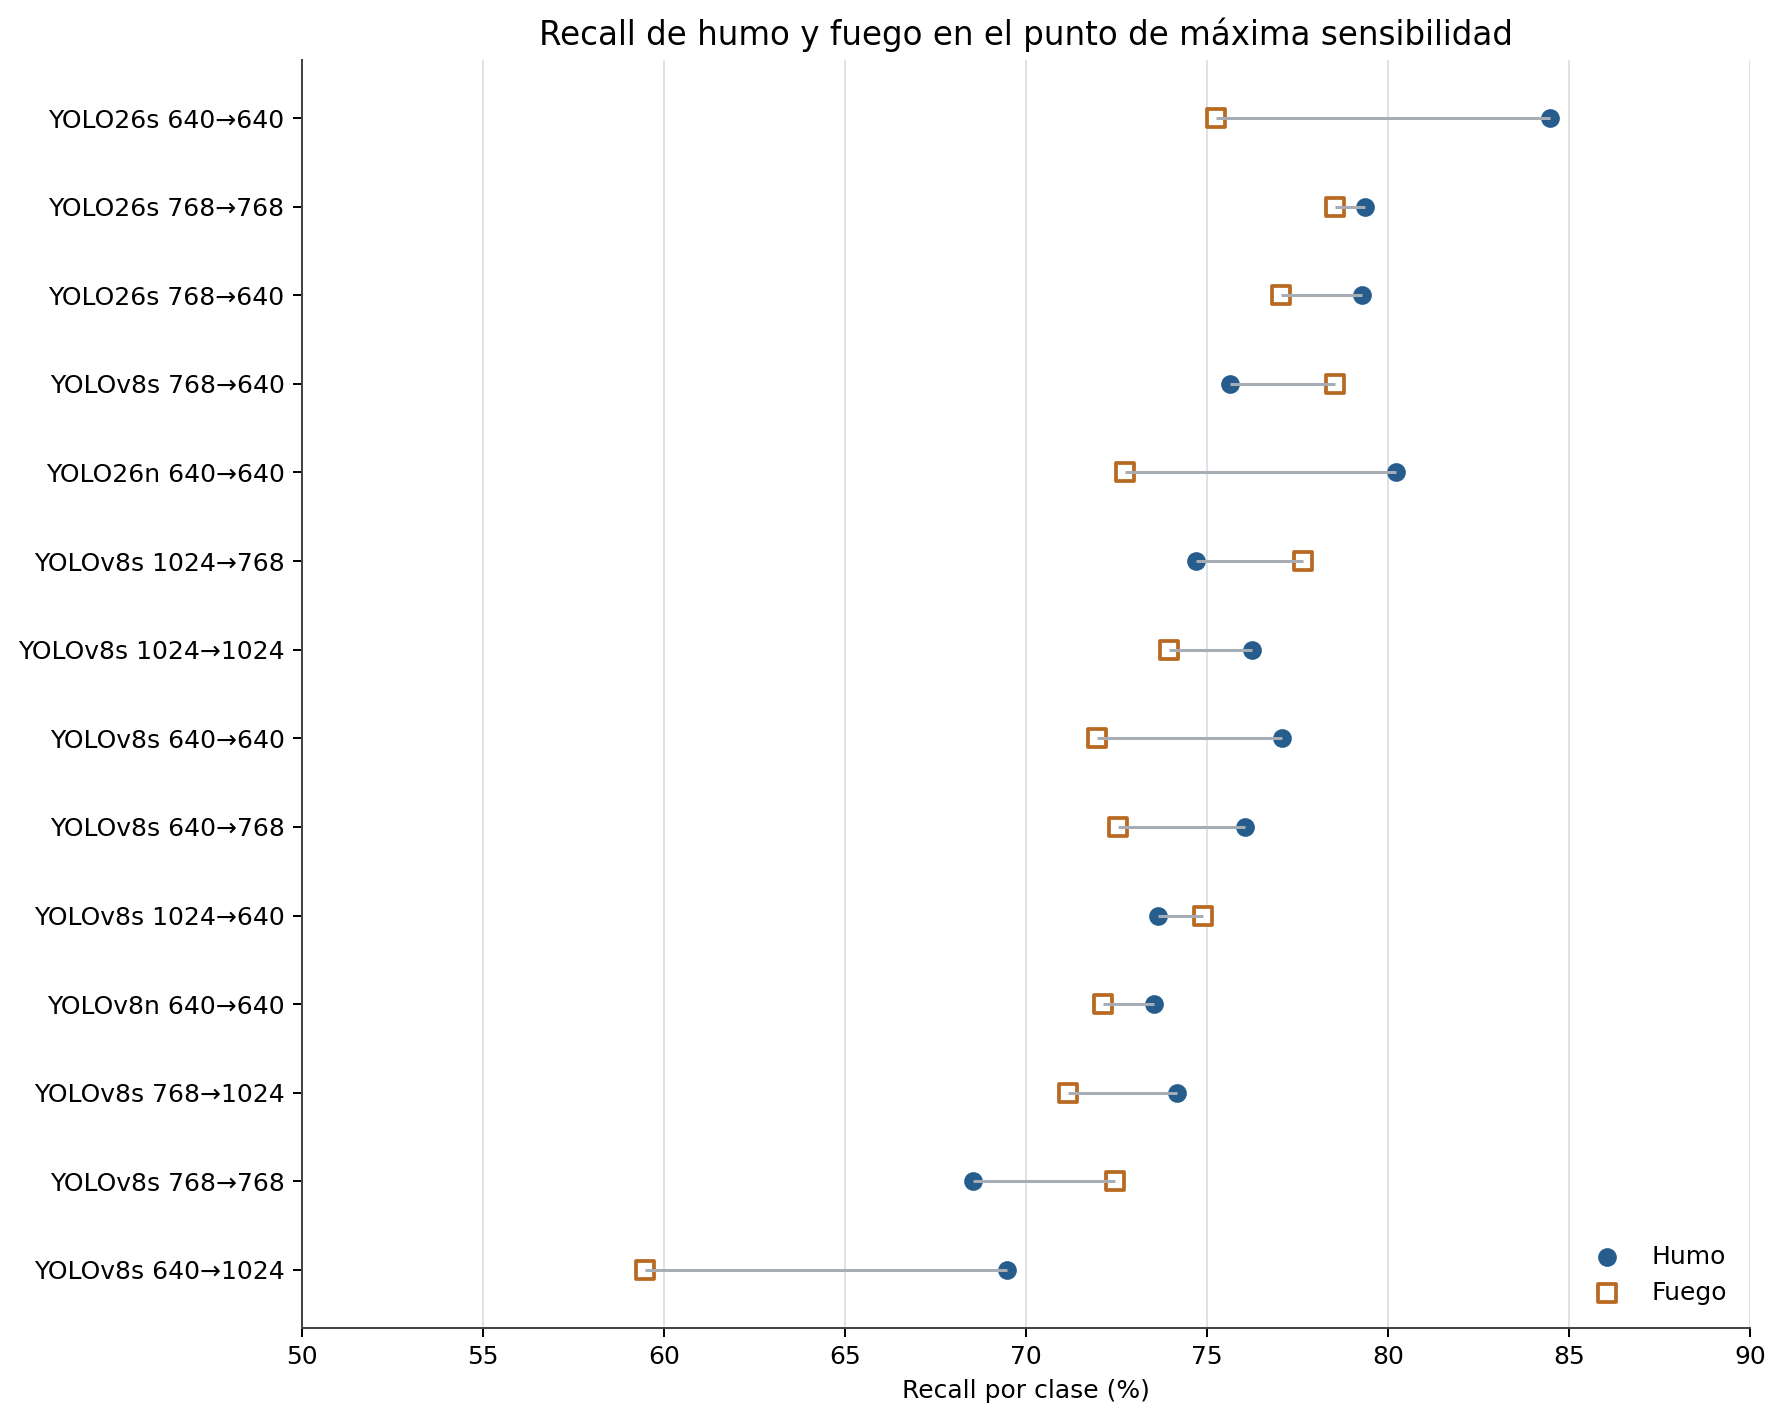

In [4]:
comparison = full_sensitivity[
    full_sensitivity.configuration.isin(["yolo26s_640_eval640", "yolo26s_768_eval768"])
][["label", "smoke_recall", "fire_recall", "minimum_class_recall", "macro_recall",
   "micro_precision", "micro_recall", "micro_f1", "smoke_fp", "fire_fp", "smoke_fn", "fire_fn"]]
display(comparison.rename(columns={
    "label": "Configuración", "smoke_recall": "Recall humo", "fire_recall": "Recall fuego",
    "minimum_class_recall": "Peor recall", "macro_recall": "Recall macro",
    "micro_precision": "Precisión", "micro_recall": "Recall micro", "micro_f1": "F1",
    "smoke_fp": "FP humo", "fire_fp": "FP fuego", "smoke_fn": "FN humo", "fire_fn": "FN fuego",
}).style.format({
    "Recall humo": "{:.2%}", "Recall fuego": "{:.2%}", "Peor recall": "{:.2%}",
    "Recall macro": "{:.2%}", "Precisión": "{:.2%}", "Recall micro": "{:.2%}", "F1": "{:.2%}",
}).hide(axis="index"))

display(Markdown(
    f"Frente a 640→640, 768→768 pierde **{100*(winner.smoke_recall-previous.smoke_recall):.2f} puntos** de recall de humo, "
    f"pero gana **{100*(previous.fire_recall-winner.fire_recall):.2f} puntos** de recall de fuego, "
    f"**{100*(previous.minimum_class_recall-winner.minimum_class_recall):.2f} puntos** en la peor clase, "
    f"**{100*(previous.micro_precision-winner.micro_precision):.2f} puntos** de precisión y "
    f"**{100*(previous.micro_f1-winner.micro_f1):.2f} puntos** de F1."
))
display(Image(filename=str(RUN_DIR / "figures" / "02_full_training_class_recall.png"), width=1100))


### 4. Ranking equilibrado: mejor F1 con el límite del 1 %

Puesto,Configuración,Umbral humo,Umbral fuego,Precisión,Recall,F1,Recall macro,Negativas con alarma
1,YOLOv8s 768→640,0.43,0.43,82.78%,70.92%,76.39%,71.55%,7
2,YOLO26s 768→768,0.33,0.32,79.33%,73.66%,76.39%,74.30%,6
3,YOLO26s 768→640,0.36,0.35,80.85%,71.44%,75.85%,72.02%,5
4,YOLOv8s 640→768,0.45,0.35,79.55%,72.10%,75.64%,72.44%,6
5,YOLOv8s 640→640,0.45,0.40,82.11%,70.07%,75.61%,70.66%,6
6,YOLOv8s 1024→1024,0.36,0.42,80.32%,71.21%,75.49%,71.94%,7
7,YOLOv8s 1024→768,0.51,0.33,79.75%,71.49%,75.39%,71.74%,6
8,YOLOv8s 1024→640,0.49,0.34,80.08%,70.31%,74.87%,70.59%,6
9,YOLOv8s 768→768,0.51,0.50,85.62%,65.86%,74.45%,66.60%,7
10,YOLO26s 640→640,0.28,0.26,74.56%,74.14%,74.35%,74.77%,6


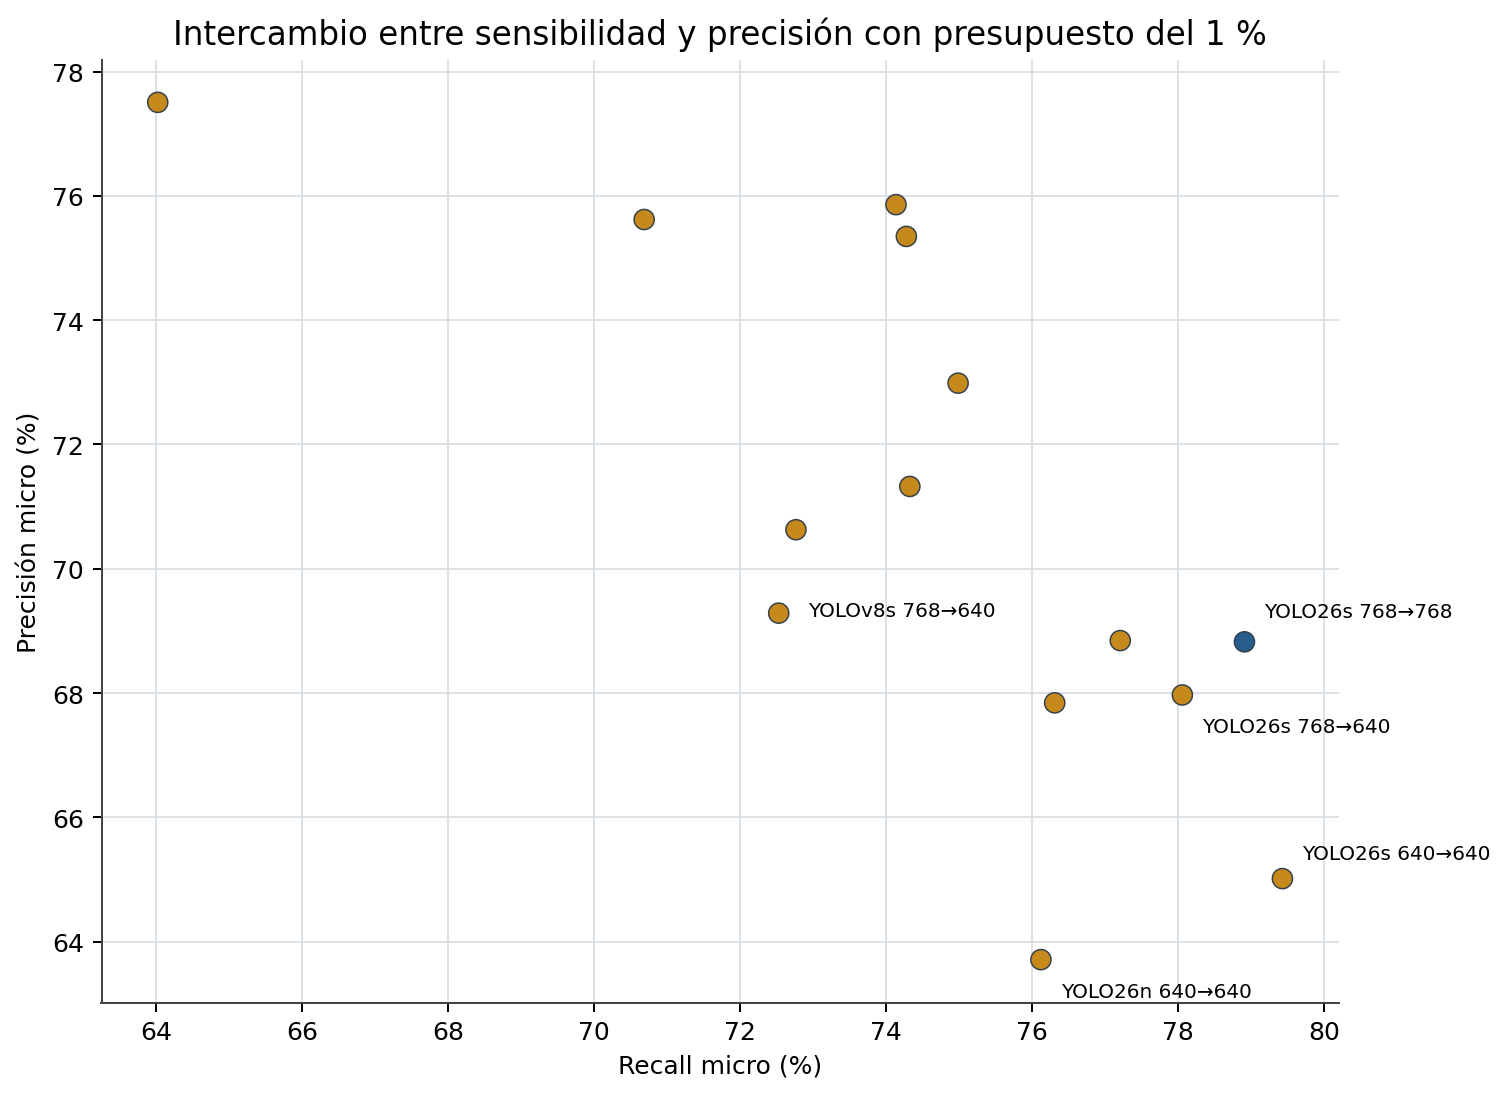

In [5]:
full_balanced = ranked[
    (ranked.comparison_group == "full_training") & (ranked.scenario == "balanced")
].sort_values("rank")
balanced_table = full_balanced[[
    "rank", "label", "smoke_threshold", "fire_threshold", "micro_precision",
    "micro_recall", "micro_f1", "macro_recall", "negative_images_with_alarm",
]].rename(columns={
    "rank": "Puesto", "label": "Configuración", "smoke_threshold": "Umbral humo",
    "fire_threshold": "Umbral fuego", "micro_precision": "Precisión", "micro_recall": "Recall",
    "micro_f1": "F1", "macro_recall": "Recall macro",
    "negative_images_with_alarm": "Negativas con alarma",
})
display(balanced_table.style.format({
    "Umbral humo": "{:.2f}", "Umbral fuego": "{:.2f}", "Precisión": "{:.2%}",
    "Recall": "{:.2%}", "F1": "{:.2%}", "Recall macro": "{:.2%}",
}).hide(axis="index"))
display(Image(filename=str(RUN_DIR / "figures" / "03_full_training_precision_recall.png"), width=950))


YOLOv8s 768→640 tiene el mayor F1, pero su ventaja sobre YOLO26s 768→768 es
de menos de una centésima de punto porcentual, y YOLO26s tiene mayor recall
medio. En F1 es, en la práctica, un empate.

### 5. Métricas estándar y por tamaño

In [6]:
standard = pd.read_csv(RUN_DIR / "standard_metrics.csv")
standard_all = standard[standard.scope == "all"][[
    "label", "precision", "recall", "mAP50", "mAP50_95", "inference_ms"
]].sort_values("mAP50_95", ascending=False)
display(standard_all.rename(columns={
    "label": "Configuración", "precision": "Precisión", "recall": "Recall",
    "mAP50_95": "mAP50-95", "inference_ms": "Inferencia ms",
}).style.format({
    "Precisión": "{:.2%}", "Recall": "{:.2%}", "mAP50": "{:.2%}",
    "mAP50-95": "{:.2%}", "Inferencia ms": "{:.3f}",
}).hide(axis="index"))

sizes = pd.read_csv(RUN_DIR / "size_metrics_sensitivity.csv")
top_sizes = sizes[sizes.configuration.isin([
    "yolo26s_640_eval640", "yolo26s_768_eval768", "yolov8s_768_eval640"
])][["label", "class_name", "size_band", "gt_boxes", "recall"]]
display(top_sizes.rename(columns={
    "label": "Configuración", "class_name": "Clase", "size_band": "Tamaño",
    "gt_boxes": "Cajas GT", "recall": "Recall",
}).style.format({"Recall": "{:.2%}"}).hide(axis="index"))


Configuración,Precisión,Recall,mAP50,mAP50-95,Inferencia ms
YOLOv8s 1024→768,80.07%,73.03%,80.26%,46.77%,2.137
YOLO26s 768→768,80.43%,74.77%,80.14%,46.68%,2.242
YOLOv8s 768→768,80.82%,72.55%,80.69%,46.57%,2.219
YOLOv8s 768→640,81.65%,74.39%,80.70%,46.52%,1.662
YOLOv8s 640→640,79.80%,72.80%,79.44%,46.42%,1.723
YOLO26s 768→640,81.05%,72.78%,79.58%,46.40%,1.657
YOLOv8s 1024→640,80.58%,72.44%,79.26%,46.24%,1.701
YOLO26s 640→640,78.12%,72.79%,79.28%,46.11%,nan
YOLOv8s 1024→1024,79.55%,74.03%,79.93%,45.68%,4.112
YOLO26n 640→640,76.65%,70.52%,76.89%,44.87%,nan


Configuración,Clase,Tamaño,Cajas GT,Recall
YOLO26s 640→640,smoke,small,188,77.13%
YOLO26s 640→640,smoke,medium,222,75.23%
YOLO26s 640→640,smoke,large,550,90.73%
YOLO26s 640→640,fire,small,760,72.24%
YOLO26s 640→640,fire,medium,324,79.63%
YOLO26s 640→640,fire,large,71,87.32%
YOLOv8s 768→640,smoke,small,188,63.30%
YOLOv8s 768→640,smoke,medium,222,63.96%
YOLOv8s 768→640,smoke,large,550,84.55%
YOLOv8s 768→640,fire,small,760,76.32%


### 6. Ensayos de hiperparámetros (50 épocas)

Puesto,Ensayo,Umbral humo,Umbral fuego,Recall humo,Recall fuego,Recall macro,Precisión,F1,Negativas con alarma
1,YOLO26s HP01 50ep 768→768,0.20,0.16,83.65%,74.63%,79.14%,66.98%,72.38%,7
2,YOLO26s HP04 50ep 768→768,0.26,0.16,81.67%,75.15%,78.41%,68.12%,72.78%,7
3,YOLO26s HP02 50ep 768→768,0.30,0.18,78.12%,73.77%,75.95%,69.50%,72.49%,7
4,YOLO26s HP03 50ep 768→768,0.27,0.16,77.81%,73.59%,75.70%,67.44%,71.25%,7


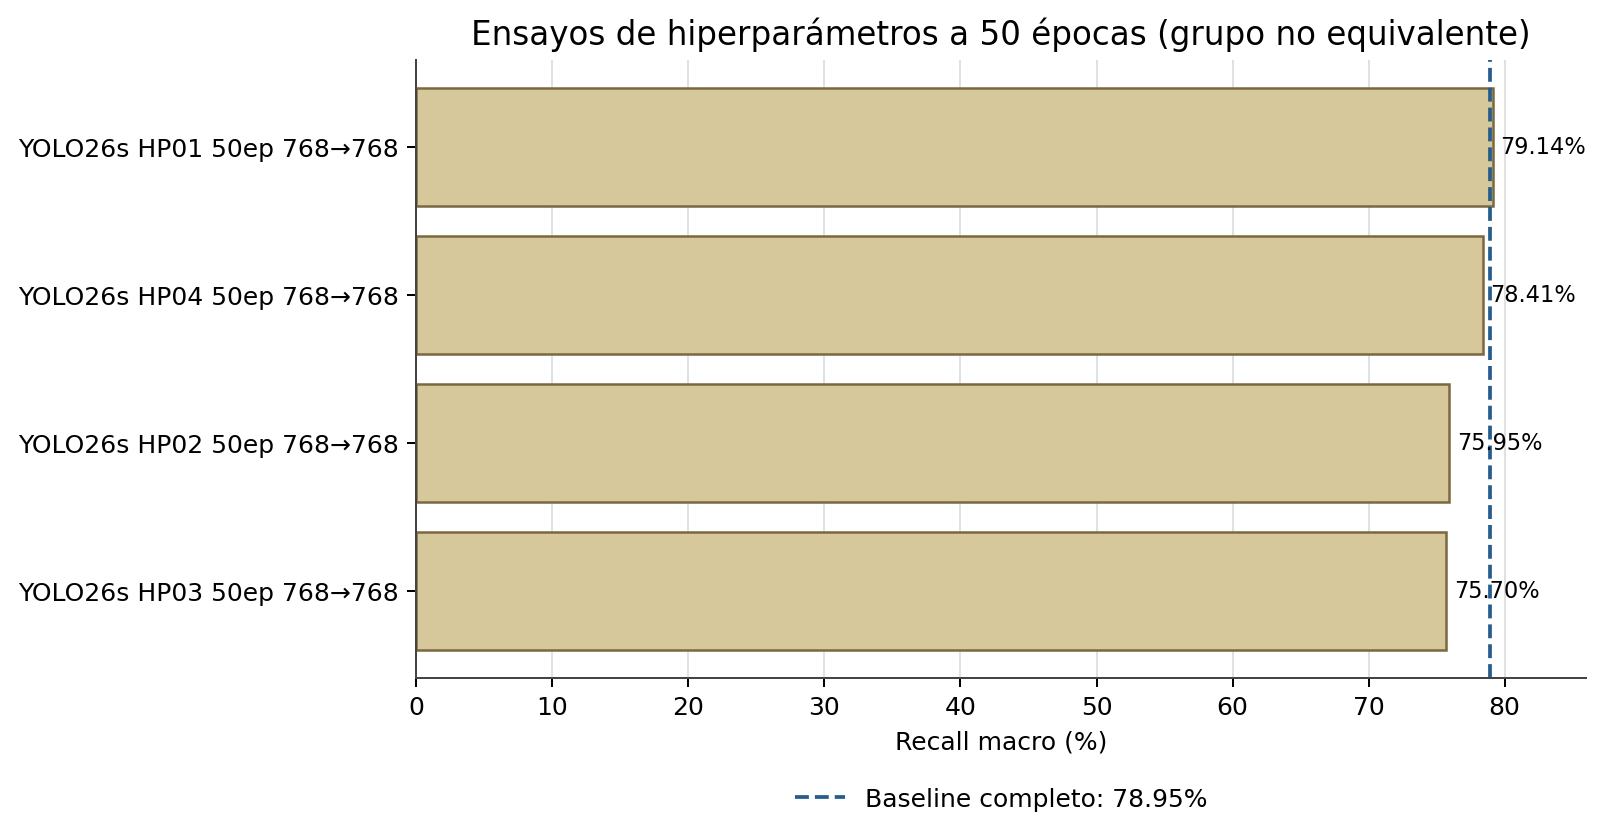

In [7]:
hp = ranked[
    (ranked.comparison_group == "hp_screening_50ep") & (ranked.scenario == "sensitivity")
].sort_values("rank")
display(hp[[
    "rank", "label", "smoke_threshold", "fire_threshold", "smoke_recall", "fire_recall",
    "macro_recall", "micro_precision", "micro_f1", "negative_images_with_alarm",
]].rename(columns={
    "rank": "Puesto", "label": "Ensayo", "smoke_threshold": "Umbral humo",
    "fire_threshold": "Umbral fuego", "smoke_recall": "Recall humo",
    "fire_recall": "Recall fuego", "macro_recall": "Recall macro",
    "micro_precision": "Precisión", "micro_f1": "F1",
    "negative_images_with_alarm": "Negativas con alarma",
}).style.format({
    "Umbral humo": "{:.2f}", "Umbral fuego": "{:.2f}", "Recall humo": "{:.2%}",
    "Recall fuego": "{:.2%}", "Recall macro": "{:.2%}", "Precisión": "{:.2%}", "F1": "{:.2%}",
}).hide(axis="index"))
display(Image(filename=str(RUN_DIR / "figures" / "04_hp_screening_macro_recall.png"), width=1000))


Se incluyen para completar la comparación, pero no compiten con los
entrenamientos completos: 50 épocas son un entrenamiento corto de prueba.

## Conclusiones

In [8]:
display(Markdown(
    "1. **Aplicación literal del criterio:** YOLO26s 640→640 gana por recall macro.  \n"
    "2. **Mejor equilibrio entre clases y mejor fuego:** YOLO26s 768→768 mantiene mayor "
    "recall de fuego, peor-clase, precisión y F1.  \n"
    "3. **Máximo F1:** YOLOv8s 768→640, empatado en la práctica con YOLO26s 768→768.  \n"
    "4. **Decisión:** se mantiene YOLO26s 768→768 con umbrales 0,36/0,16, el modelo "
    "elegido en el notebook 09, por su mejor equilibrio entre clases y su mayor recall de fuego."
))


1. **Aplicación literal del criterio:** YOLO26s 640→640 gana por recall macro.  
2. **Mejor equilibrio entre clases y mejor fuego:** YOLO26s 768→768 mantiene mayor recall de fuego, peor-clase, precisión y F1.  
3. **Máximo F1:** YOLOv8s 768→640, empatado en la práctica con YOLO26s 768→768.  
4. **Decisión:** se mantiene YOLO26s 768→768 con umbrales 0,36/0,16, el modelo elegido en el notebook 09, por su mejor equilibrio entre clases y su mayor recall de fuego.